# Ping Pong Ball Prediction Using Transfer Learning:

Inputs:
- x y z (frame 1)
- x y z (frame 2)
- x y z (frame 3)
- x y z (frame 4)
- x y z (frame 5)
- x y z (frame 6)
- dt12
- dt23
- dt34
- dt45
- dt56


Outputs:
- x y z (interception)
- vx vy vz
- t_hit



## Importing the Libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

### Importing the Dataset

In [2]:
dataset = pd.read_csv('../learning_data/synthetic_data/synthetic_intercept_dataset.csv')

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   x1                     20000 non-null  float64
 1   y1                     20000 non-null  float64
 2   z1                     20000 non-null  float64
 3   x2                     20000 non-null  float64
 4   y2                     20000 non-null  float64
 5   z2                     20000 non-null  float64
 6   x3                     20000 non-null  float64
 7   y3                     20000 non-null  float64
 8   z3                     20000 non-null  float64
 9   x4                     20000 non-null  float64
 10  y4                     20000 non-null  float64
 11  z4                     20000 non-null  float64
 12  x5                     20000 non-null  float64
 13  y5                     20000 non-null  float64
 14  z5                     20000 non-null  float64
 15  x6

In [4]:
dataset.describe()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,bounces_before_hit,has_bounce_before_hit,intercept_valid,x0,y0,z0,vx0,vy0,vz0,gravity_z_mm_s2
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.00000,20000.000000,20000.0,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.0
mean,2.846180,2586.805399,-800.782866,2.587758,2516.164890,-830.432964,2.335908,2445.474348,-857.060668,2.063134,...,1.15260,0.957000,1.0,2.846180,2586.805399,-800.782866,-16.938254,-4560.467929,-2008.859992,-9810.0
std,611.462974,375.072852,203.189690,589.374269,397.389140,201.130733,568.209203,420.543096,195.828620,548.091609,...,0.46403,0.202862,0.0,611.462974,375.072852,203.189690,2055.477303,1858.306767,1790.670399,0.0
min,-1062.362775,1940.034250,-1150.718078,-1063.103457,1765.688301,-1150.553726,-1064.714239,1589.401180,-1150.412514,-1069.299827,...,0.00000,0.000000,1.0,-1062.362775,1940.034250,-1150.718078,-5389.215897,-10000.000000,-5579.934696,-9810.0
25%,-528.535366,2260.726977,-977.935437,-509.131333,2172.421868,-1011.389874,-487.865675,2084.232867,-1040.274206,-467.281644,...,1.00000,1.000000,1.0,-528.535366,2260.726977,-977.935437,-1493.140882,-5785.656253,-3529.333450,-9810.0
50%,3.959062,2585.280814,-801.336626,1.937988,2515.546526,-832.605819,1.703397,2442.896152,-868.113493,1.632830,...,1.00000,1.000000,1.0,3.959062,2585.280814,-801.336626,-20.485697,-4299.572021,-2039.711058,-9810.0
75%,529.412526,2912.452341,-622.844420,508.848227,2861.943378,-654.383173,490.945488,2810.925219,-688.377206,474.061369,...,1.00000,1.000000,1.0,529.412526,2912.452341,-622.844420,1442.721220,-3122.030705,-599.665230,-9810.0
max,1062.362428,3239.991853,-450.793865,1062.991701,3220.357264,-424.677132,1065.423516,3204.612203,-395.711871,1067.941189,...,2.00000,1.000000,1.0,1062.362428,3239.991853,-450.793865,5259.466574,-816.493459,2414.174822,-9810.0


### Pre-Processing

### Separating the Input and Outputs

In [5]:

input_cols_6 = [
    "x1", "y1", "z1",
    "x2", "y2", "z2",
    "x3", "y3", "z3",
    "x4", "y4", "z4",
    "x5", "y5", "z5",
    "x6", "y6", "z6",
    "dt12", "dt23", "dt34", "dt45", "dt56",
]
target_cols = ["x_hit", "y_hit", "z_hit", "vx_hit", "vy_hit", "vz_hit", "t_hit"]

x = dataset[input_cols_6]
y = dataset[target_cols]


In [6]:
# View the inputs
print(x)

               x1           y1           z1          x2           y2  \
0     -129.883316  3056.177296  -662.582380  -82.613370  3020.750138   
1     -637.695070  1949.570951  -599.892936 -598.290176  1818.696515   
2      981.532537  3121.154898  -660.945006  979.224710  3084.695960   
3     -129.813147  1968.095704  -572.335653 -156.440657  1812.347335   
4     -403.062195  2950.626290  -470.461502 -415.733914  2903.238033   
...           ...          ...          ...         ...          ...   
19995 -569.758900  1956.017896  -541.428463 -548.070337  1834.083464   
19996 -576.209725  1945.075686  -657.666635 -542.943741  1825.041555   
19997   -0.633386  2788.299177  -802.618530   18.380385  2696.490869   
19998  928.145514  3204.306094 -1082.108162  877.262426  3156.054259   
19999  584.466916  2829.469475  -779.738803  538.987805  2785.366693   

                z2          x3           y3           z3          x4  ...  \
0      -652.486762  -39.135189  2988.164773  -645.857170  

In [7]:
# View the outputs
print(y)

             x_hit        y_hit        z_hit       vx_hit       vy_hit  \
0      1371.275360  1931.111771  -754.428699  2680.640491 -2009.045581   
1       -22.823035   -92.587337 -1011.623073  2411.262880 -8008.463872   
2       784.524643     8.834025  -954.400194  -131.777856 -2081.819982   
3      -430.184554   211.177523  -817.838405 -1580.902144 -9246.937796   
4     -1288.275025  -359.792069  -317.001280  -815.864359 -3051.076828   
...            ...          ...          ...          ...          ...   
19995  -251.299871   165.621686  -817.065476  1224.842421 -6886.139268   
19996   -41.939604    17.261082  -819.872175  2016.113666 -7274.772092   
19997   552.542952   117.278195  -268.933929  1084.659487 -5237.296043   
19998 -1363.733066  1030.944538   -64.595064 -3420.714299 -3243.823218   
19999 -1114.591436  1181.829511  -764.898660 -2855.560255 -2769.142797   

            vz_hit     t_hit  
0      1496.186381  0.479680  
1      3222.377021  0.174478  
2     -2404.186073

In [8]:
x = x.values
y = y.values

### Splitting the Dataset into the Training set and Test set

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1) Build reachability vector from your full dataset
# (change column name if needed)
r = dataset["is_reachable"].to_numpy().astype(int)

# 2) Split x, y, and r together (important)
x_train, x_test, y_train, y_test, r_train, r_test = train_test_split(
    x, y, r,
    test_size=0.05,
    random_state=5,
    stratify=r   # recommended
)

# 3) Keep full test copy
x_test_all = x_test.copy()
y_test_all = y_test.copy()

# 4) Reachable-only adjusted test set
mask_reach = (r_test == 1)
x_test_reach = x_test_all[mask_reach].copy()
y_test_reach = y_test_all[mask_reach].copy()


In [10]:
print(x_train.shape)
print(x_test_all.shape)
print(x_test_reach.shape)
print(y_train.shape)
print(y_test_all.shape)
print(y_test_reach.shape)

(19000, 23)
(1000, 23)
(236, 23)
(19000, 7)
(1000, 7)
(236, 7)


### Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scx = StandardScaler()
scy = StandardScaler()

x_train = scx.fit_transform(x_train)
x_test_all = scx.transform(x_test_all)
x_test_reach = scx.transform(x_test_reach)

y_train = scy.fit_transform((y_train))
y_test_all = scy.transform((y_test_all))
y_test_reach = scy.transform((y_test_reach))

In [12]:
# --- weighted loss + sample weighting helpers (xyz emphasis + center/reach emphasis) ---
import tensorflow as tf
import numpy as np

@tf.keras.utils.register_keras_serializable(package="Custom")
def weighted_mse(y_true, y_pred):
    # Output order: [x_hit, y_hit, z_hit, vx_hit, vy_hit, vz_hit, t_hit]
    raw_w = tf.constant([8.0, 8.0, 8.0, 0.5, 0.5, 0.5, 1.0], dtype=tf.float32)
    w = raw_w / tf.reduce_mean(raw_w)
    err2 = tf.square(y_true - y_pred)
    return tf.reduce_mean(err2 * w)

WORKSPACE_CENTER_MM = np.array([0.0, 0.0, -900.0], dtype=np.float32)
CENTER_SIGMA_MM = 250.0
REACH_BOOST = 1.0
CENTER_BOOST = 2.0

def build_sample_weights(y_train_scaled, y_scaler, reachable_vec=None,
                         center=WORKSPACE_CENTER_MM,
                         sigma_mm=CENTER_SIGMA_MM,
                         reach_boost=REACH_BOOST,
                         center_boost=CENTER_BOOST):
    y_u = y_scaler.inverse_transform(y_train_scaled)
    d_mm = np.linalg.norm(y_u[:, :3] - center[None, :], axis=1)

    w_center = 1.0 + center_boost * np.exp(-(d_mm ** 2) / (2.0 * sigma_mm ** 2))
    if reachable_vec is None:
        w_reach = np.ones_like(w_center)
    else:
        w_reach = 1.0 + reach_boost * np.asarray(reachable_vec, dtype=float)

    w = w_center * w_reach
    w = w / np.mean(w)
    return np.clip(w, 0.5, 5.0)

# Broad-stage sample weights (r_train comes from the broad train/test split cell)
sample_w_broad = build_sample_weights(y_train, scy, reachable_vec=r_train)
print("sample_w_broad stats:", sample_w_broad.min(), sample_w_broad.mean(), sample_w_broad.max())


sample_w_broad stats: 0.5997522053511476 1.0 3.5957405659807993


## The ANN Model Initialization

In [13]:
ball_predictor = tf.keras.models.Sequential()

### Constructing the Model

In [14]:

ball_predictor.add(tf.keras.layers.Dense(units=23, activation='relu')) # 23 input features (6 points + 5 dt)
ball_predictor.add(tf.keras.layers.Dense(units=32, activation='relu')) # hiddel layer 1
ball_predictor.add(tf.keras.layers.Dense(units=64, activation='relu')) # hidden layer 2
ball_predictor.add(tf.keras.layers.Dense(units=32, activation='relu')) # hiddel layer 3
ball_predictor.add(tf.keras.layers.Dense(units=7, activation='linear')) # 7


In [15]:
ball_predictor.compile(
    loss=weighted_mse,
    optimizer='adam',
    metrics=['mean_squared_error']
)


### Training

In [16]:
p1 = ball_predictor.fit(
    x_train,
    y_train,
    sample_weight=sample_w_broad,
    validation_split=0.2,
    batch_size=32,
    epochs=80,
    verbose=1,
)


Epoch 1/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7508 - mean_squared_error: 0.7010 - val_loss: 0.6149 - val_mean_squared_error: 0.5878
Epoch 2/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4088 - mean_squared_error: 0.4376 - val_loss: 0.2382 - val_mean_squared_error: 0.3057
Epoch 3/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1938 - mean_squared_error: 0.2604 - val_loss: 0.1658 - val_mean_squared_error: 0.2314
Epoch 4/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1417 - mean_squared_error: 0.2046 - val_loss: 0.1369 - val_mean_squared_error: 0.1934
Epoch 5/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1160 - mean_squared_error: 0.1760 - val_loss: 0.1119 - val_mean_squared_error: 0.1717
Epoch 6/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1015 - mean_squared_error: 0.1610 - val_loss: 0.0968 - val_mean_squared_error: 0.1571
Epoch 7/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0920 - mean_squared_error: 0.1504 - val_loss: 0.08

### Learning Curves

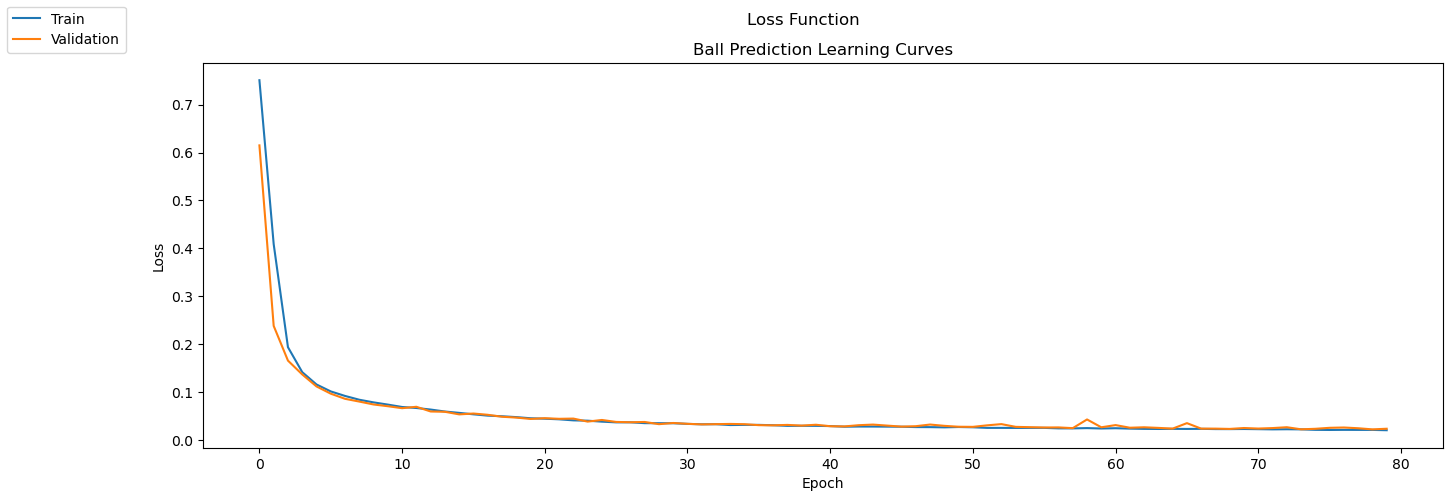

In [17]:
fig, axs = plt.subplots(figsize=(16,5))
fig.suptitle('Loss Function')

axs.plot(p1.history['loss'])
axs.plot(p1.history['val_loss'])
axs.set_title("Ball Prediction Learning Curves")
axs.set(xlabel='Epoch', ylabel='Loss')

fig.legend(labels=['Train', 'Validation'], loc="upper left")
plt.show()

In [18]:
# def eval_regression(name, y_true, y_pred):
#     mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput='raw_values'))
#     print(f"\n{name}")
#     print("MAE per output:", mae)
#     print("RMSE per output:", rmse)

# # If y is scaled, inverse-transform both y_true and y_pred before metrics.
# y_pred_all = ball_predictor.predict(x_test_all)
# y_pred_reach = ball_predictor.predict(x_test_reach)

# # Example for scaled targets:
# # y_pred_all = scy.inverse_transform(y_pred_all); y_test_all_eval = scy.inverse_transform(y_test_all)
# # y_pred_reach = scy.inverse_transform(y_pred_reach); y_test_reach_eval = scy.inverse_transform(y_test_reach)

# eval_regression("All test shots", y_test_all, y_pred_all)
# eval_regression("Reachable-only test shots", y_test_reach, y_pred_reach)

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

target_names = ["x_hit", "y_hit", "z_hit", "vx_hit", "vy_hit", "vz_hit", "t_hit"]
target_units = ["mm", "mm", "mm", "mm/s", "mm/s", "mm/s", "ms"]

def eval_with_units(name, model, x_eval, y_eval, y_scaler, y_is_scaled=True, t_hit_in_seconds=True):
    y_pred = model.predict(x_eval, verbose=0)

    # Convert to physical units exactly once
    if y_is_scaled:
        assert y_eval.shape[1] == y_scaler.n_features_in_ == len(target_names)
        y_true_u = y_scaler.inverse_transform(y_eval)
        y_pred_u = y_scaler.inverse_transform(y_pred)
    else:
        y_true_u = y_eval
        y_pred_u = y_pred

    err = y_pred_u - y_true_u
    abs_err = np.abs(err)

    mae = mean_absolute_error(y_true_u, y_pred_u, multioutput="raw_values")
    rmse = np.sqrt(mean_squared_error(y_true_u, y_pred_u, multioutput="raw_values"))
    std_abs = abs_err.std(axis=0)

    # Convert t_hit to ms for reporting (only if stored in seconds)
    if t_hit_in_seconds:
        i = target_names.index("t_hit")
        mae[i] *= 1000.0
        rmse[i] *= 1000.0
        std_abs[i] *= 1000.0

    report = pd.DataFrame({
        "target": target_names,
        "unit": target_units,
        "MAE": mae,
        "RMSE": rmse,
        "STD_abs_error": std_abs,
    })

    print(f"\n{name}")
    print(report.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

# Run both:
eval_with_units("All test shots", ball_predictor, x_test_all, y_test_all, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units("Reachable-only test shots", ball_predictor, x_test_reach, y_test_reach, scy, y_is_scaled=True, t_hit_in_seconds=True)




All test shots
target unit     MAE    RMSE  STD_abs_error
 x_hit   mm  43.098  59.003         40.297
 y_hit   mm  60.326  86.064         61.382
 z_hit   mm  40.275  55.257         37.833
vx_hit mm/s 166.511 213.789        134.090
vy_hit mm/s 128.977 163.957        101.228
vz_hit mm/s 586.022 953.438        752.079
 t_hit   ms  24.025  34.990         25.438

Reachable-only test shots
target unit     MAE      RMSE  STD_abs_error
 x_hit   mm  39.764    51.857         33.285
 y_hit   mm  77.157   108.755         76.645
 z_hit   mm  33.060    46.607         32.851
vx_hit mm/s 165.508   217.018        140.370
vy_hit mm/s 132.633   168.710        104.266
vz_hit mm/s 688.310 1,104.090        863.276
 t_hit   ms  25.093    33.215         21.763


In [19]:
# Verification 
train_std = scy.scale_ 
rmse_sigma = np.sqrt(0.1084)   # val_mse from curve, e.g. 0.1151
rmse_units = rmse_sigma * train_std

print(rmse_units)


[2.46111357e+02 1.74021575e+02 1.17381984e+02 6.76623218e+02
 6.11727608e+02 7.15997819e+02 9.31626992e-02]


## Loading the Matched Synthetic Dataset (Transfer Learning)

In [20]:
matched_dataset = pd.read_csv('../learning_data/synthetic_matched_data/synthetic_intercept_dataset.csv')
matched_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   x1                     10000 non-null  float64
 1   y1                     10000 non-null  float64
 2   z1                     10000 non-null  float64
 3   x2                     10000 non-null  float64
 4   y2                     10000 non-null  float64
 5   z2                     10000 non-null  float64
 6   x3                     10000 non-null  float64
 7   y3                     10000 non-null  float64
 8   z3                     10000 non-null  float64
 9   x4                     10000 non-null  float64
 10  y4                     10000 non-null  float64
 11  z4                     10000 non-null  float64
 12  x5                     10000 non-null  float64
 13  y5                     10000 non-null  float64
 14  z5                     10000 non-null  float64
 15  x6 

In [21]:
input_cols_6 = [
    "x1", "y1", "z1",
    "x2", "y2", "z2",
    "x3", "y3", "z3",
    "x4", "y4", "z4",
    "x5", "y5", "z5",
    "x6", "y6", "z6",
    "dt12", "dt23", "dt34", "dt45", "dt56",
]
target_cols = ["x_hit", "y_hit", "z_hit", "vx_hit", "vy_hit", "vz_hit", "t_hit"]

x_matched = matched_dataset[input_cols_6]
y_matched = matched_dataset[target_cols]
r_matched = matched_dataset["is_reachable"].to_numpy().astype(int)

# View the inputs
print(x_matched)
print(y_matched)

x_matched = x_matched.values
y_matched = y_matched.values


              x1           y1           z1          x2           y2  \
0      89.384098  2497.130664  -507.592687   88.530663  2470.751062   
1     -25.181972  2465.962700  -591.888417  -23.676343  2437.120467   
2      26.115563  2425.404595  -794.090581   16.715099  2399.819544   
3    -278.851328  2408.352866  -379.653193 -270.862368  2362.167014   
4    -282.926270  2417.636907  -404.155517 -278.312044  2395.463430   
...          ...          ...          ...         ...          ...   
9995   35.808687  2441.757114  -793.605519   25.008045  2391.264699   
9996 -436.476024  2431.436673  -562.554997 -431.358869  2391.018892   
9997 -209.032818  2493.414134  -483.535914 -197.653580  2454.246241   
9998  244.304104  2395.044847  -764.802932  254.788196  2367.043198   
9999 -286.839773  2444.128254 -1044.094322 -266.168965  2390.783190   

               z2          x3           y3           z3          x4  ...  \
0     -551.027299   89.996010  2446.577520  -594.742439   96.775159  ..

In [22]:
#Split input and output x, y
x_matched_train, x_matched_test, y_matched_train, y_matched_test, r_matched_train, r_matched_test = train_test_split(
    x_matched, y_matched, r_matched,
    test_size=0.1,
    random_state=4,
    stratify=r_matched
)


In [23]:
print(x_matched_train.shape)
print(x_matched_test.shape)
print(y_matched_train.shape)
print(y_matched_test.shape)

x_matched_train_s = scx.transform(x_matched_train)
x_matched_test_s = scx.transform(x_matched_test)
y_matched_train_s = scy.transform(y_matched_train)
y_matched_test_s = scy.transform(y_matched_test)

sample_w_matched = build_sample_weights(y_matched_train_s, scy, reachable_vec=r_matched_train)
print("sample_w_matched stats:", sample_w_matched.min(), sample_w_matched.mean(), sample_w_matched.max())


(9000, 23)
(1000, 23)
(9000, 7)
(1000, 7)
sample_w_matched stats: 0.55494654335364 0.9999999999999998 1.615147405692436


In [24]:
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

# Try 1e-5 first; then tune [1e-6, 1e-5, 5e-5]
L2_LAMBDA = 1e-5

dense_total = sum(isinstance(l, tf.keras.layers.Dense) for l in ball_predictor.layers)
dense_seen = {"n": 0}

def clone_with_l2(layer):
    cfg = layer.get_config()
    if isinstance(layer, tf.keras.layers.Dense):
        dense_seen["n"] += 1
        is_output_layer = (dense_seen["n"] == dense_total)
        if not is_output_layer:  # regularize hidden layers only
            cfg["kernel_regularizer"] = regularizers.serialize(regularizers.l2(L2_LAMBDA))
    return layer.__class__.from_config(cfg)

# Start from broad pretrained model, but with L2 regularization added
transfer_model_matched = tf.keras.models.clone_model(
    ball_predictor,
    clone_function=clone_with_l2
)
transfer_model_matched.set_weights(ball_predictor.get_weights())

# Matched stage: unfreeze all layers, train with low LR
for layer in transfer_model_matched.layers:
    layer.trainable = True

transfer_model_matched.compile(
    loss=weighted_mse,
    optimizer=Adam(learning_rate=1e-4),
    metrics=["mean_squared_error"]
)

history_matched = transfer_model_matched.fit(
    x_matched_train_s, y_matched_train_s,
    sample_weight=sample_w_matched,
    validation_split=0.2,
    epochs=40,
    verbose=1
)


Epoch 1/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0361 - mean_squared_error: 0.1465 - val_loss: 0.0322 - val_mean_squared_error: 0.1364
Epoch 2/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0324 - mean_squared_error: 0.1366 - val_loss: 0.0305 - val_mean_squared_error: 0.1317
Epoch 3/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0309 - mean_squared_error: 0.1322 - val_loss: 0.0294 - val_mean_squared_error: 0.1268
Epoch 4/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0299 - mean_squared_error: 0.1279 - val_loss: 0.0287 - val_mean_squared_error: 0.1240
Epoch 5/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0292 - mean_squared_error: 0.1246 - val_loss: 0.0282 - val_mean_squared_error: 0.1226
Epoch 6/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0286 - mean_squared_error: 0.1222 - val_loss: 0.0278 - val_mean_squared_error: 0.1207
Epoch 7/40
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0283 - mean_squared_error: 0.1212 - val_loss: 0.02

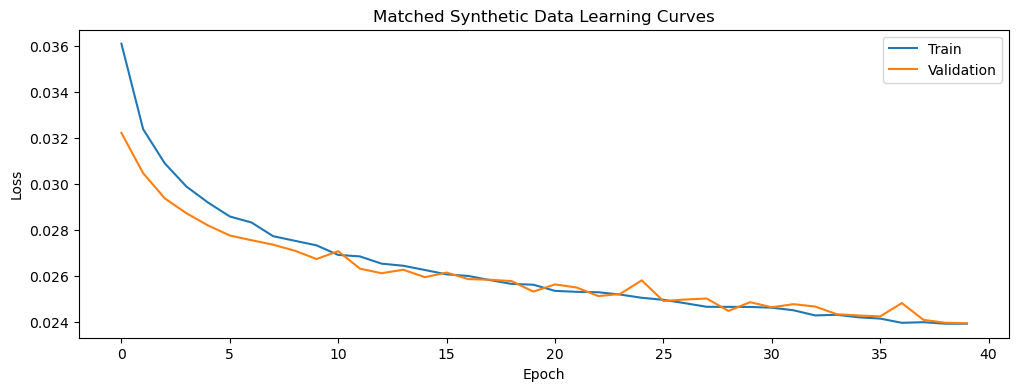

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(history_matched.history["loss"], label="Train")
ax.plot(history_matched.history["val_loss"], label="Validation")
ax.set_title("Matched Synthetic Data Learning Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()

In [26]:
eval_with_units(
    "Matched Data Transfer Model",
    transfer_model_matched,
    x_matched_test_s,
    y_matched_test_s,
    scy,
    y_is_scaled=True,
    t_hit_in_seconds=True
)


Matched Data Transfer Model
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm    39.170    50.280         31.524
 y_hit   mm    46.804    59.969         37.492
 z_hit   mm    27.335    35.989         23.409
vx_hit mm/s    69.685    88.772         54.995
vy_hit mm/s    72.034    91.393         56.247
vz_hit mm/s 1,149.329 1,857.254      1,458.916
 t_hit   ms    24.552    31.624         19.931


## Loading the Real Dataset (Transfer Learning)

In [27]:
real_dataset = pd.read_csv('../learning_data/real_data/real_transfer_predictor_verified_clean.csv')
real_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sample_id           102 non-null    int64  
 1   captured_at         102 non-null    object 
 2   x1                  102 non-null    float64
 3   y1                  102 non-null    float64
 4   z1                  102 non-null    float64
 5   x2                  102 non-null    float64
 6   y2                  102 non-null    float64
 7   z2                  102 non-null    float64
 8   x3                  102 non-null    float64
 9   y3                  102 non-null    float64
 10  z3                  102 non-null    float64
 11  x4                  102 non-null    float64
 12  y4                  102 non-null    float64
 13  z4                  102 non-null    float64
 14  x5                  102 non-null    float64
 15  y5                  102 non-null    float64
 16  z5      

In [28]:
real_dataset.describe()

,sample_id,x1,y1,z1,x2,y2,z2,x3,y3,z3,...,x_hit,y_hit,z_hit,vx_hit,vy_hit,vz_hit,t_hit,is_reachable,intercept_valid,bounces_before_hit
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,...,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.0,102.0,102.000000
mean,55.186275,113.445545,2481.107347,-735.691062,116.269819,2413.973788,-756.405619,115.244868,2347.193116,-777.832314,...,45.803787,8.496171,-856.813536,-55.186871,-1939.008776,-561.778747,0.832062,1.0,1.0,0.441176
std,30.674184,319.085833,121.208627,224.743203,312.382678,116.942937,242.468372,305.158921,112.075331,259.165467,...,297.137013,131.877543,57.766482,314.890082,342.237235,1316.196233,0.142155,0.0,0.0,0.498980
min,1.000000,-424.139309,1376.753747,-1088.880989,-400.960797,1349.684935,-1108.415713,-396.451038,1330.610550,-1114.560918,...,-612.197110,-385.745273,-1017.808779,-875.828997,-3125.673335,-2403.803700,0.481092,1.0,1.0,0.000000
25%,30.250000,-185.539421,2465.033403,-917.677502,-159.252234,2398.240459,-953.255903,-152.810850,2332.178875,-1000.198216,...,-210.574879,-61.188492,-884.951474,-152.021290,-2137.911071,-1522.401428,0.735493,1.0,1.0,0.000000
50%,55.500000,121.963376,2492.248825,-806.129483,133.435652,2425.629614,-845.678118,128.282817,2361.734204,-872.024670,...,117.355166,5.861416,-844.951417,-17.123231,-1906.432176,-1023.955444,0.810567,1.0,1.0,0.000000
75%,80.750000,355.598998,2521.889374,-558.255463,359.352332,2454.973839,-548.212031,355.157908,2384.958005,-543.971916,...,272.615927,74.683613,-804.628420,91.245513,-1698.928112,779.190902,0.920944,1.0,1.0,1.000000
max,107.000000,778.574600,2578.329790,-202.463462,767.789459,2521.317811,-224.895161,756.187685,2464.327618,-236.286537,...,619.598548,280.947165,-800.079216,661.044003,-1142.194414,2314.541399,1.264158,1.0,1.0,1.000000


### Pre-Processing the Real Dataset

In [29]:

input_cols_6 = [
    "x1", "y1", "z1",
    "x2", "y2", "z2",
    "x3", "y3", "z3",
    "x4", "y4", "z4",
    "x5", "y5", "z5",
    "x6", "y6", "z6",
    "dt12", "dt23", "dt34", "dt45", "dt56",
]
target_cols = ["x_hit", "y_hit", "z_hit", "vx_hit", "vy_hit", "vz_hit", "t_hit"]

x_real = real_dataset[input_cols_6]
y_real = real_dataset[target_cols]


In [30]:
# View the inputs
print(x_real)

             x1           y1           z1          x2           y2  \
0     17.057403  2488.654688 -1059.231099   13.965808  2401.042538   
1   -371.660861  2562.756415  -902.337499 -363.831118  2492.365082   
2    348.988339  2530.440019 -1019.428264  346.543998  2455.846440   
3   -339.351594  2578.329790 -1088.880989 -338.167709  2521.317811   
4    606.993396  2514.340931  -959.900229  617.580909  2462.769555   
..          ...          ...          ...         ...          ...   
97   347.393442  2513.380763  -837.735261  359.388014  2444.685893   
98   147.748628  2540.914774  -948.471107  166.410486  2473.010504   
99   778.574600  2413.757989  -475.275458  767.789459  2361.251185   
100  503.323972  2356.436827  -229.299041  500.385245  2302.072589   
101 -113.447210  2470.912318  -314.627031 -111.778994  2407.764608   

              z2          x3           y3           z3          x4  ...  \
0   -1108.415713   16.430451  2332.622645 -1080.383280   11.984324  ...   
1    -953

In [31]:
# View the inputs
print(y_real)

          x_hit       y_hit       z_hit      vx_hit       vy_hit       vz_hit  \
0     -4.641024    4.358949 -871.436038  -24.221133 -2421.730067   704.516383   
1    406.220234  113.632881 -806.213728  559.027545 -1784.209457  -239.937665   
2    195.766794   30.848722 -801.231740 -136.388611 -2090.589103   414.346604   
3   -233.764694  239.451476 -801.823987   79.766397 -1867.498690  1705.369142   
4    323.498877  -64.604830 -828.768999 -248.830649 -2121.369813  -753.121741   
..          ...         ...         ...         ...          ...          ...   
97   193.839881  -19.301921 -885.549040 -137.302534 -1910.219734  -583.161809   
98   127.766898  -11.573475 -890.456844  -33.863654 -1902.644618  -956.554854   
99   296.566195  -85.472919 -877.207377 -345.538103 -1796.118893 -1963.216922   
100  475.026525  -33.738712 -884.099688  -18.932829 -1723.216687 -2403.803700   
101  -99.758850 -269.164879 -804.681175    9.105959 -1944.024326 -1897.377825   

        t_hit  
0    0.6460

In [32]:
x_real = x_real.values
y_real = y_real.values

### Splitting the Dataset into the Training set and Test set

In [33]:
#Split input and output x, y
x_real_train, x_real_test, y_real_train, y_real_test= train_test_split(
    x_real, y_real,
    test_size=0.2,
    random_state=4
    

)


In [34]:
print(x_real_train.shape)
print(x_real_test.shape)
print(y_real_train.shape)
print(y_real_test.shape)

(81, 23)
(21, 23)
(81, 7)
(21, 7)


### Scaling the real dataset

In [35]:
x_real_train_s = scx.transform(x_real_train)
x_real_test_s = scx.transform(x_real_test)
y_real_train_s = scy.transform(y_real_train)
y_real_test_s = scy.transform(y_real_test)

# Real dataset is mostly/all reachable in this collection; use center emphasis.
sample_w_real = build_sample_weights(
    y_real_train_s,
    scy,
    reachable_vec=np.ones(y_real_train_s.shape[0], dtype=int),
)
print("sample_w_real stats:", sample_w_real.min(), sample_w_real.mean(), sample_w_real.max())


sample_w_real stats: 0.534480807215898 0.9999999999999998 1.497342705639991


In [36]:
# ### WEighting the xyz more than velocities

# # Output order must match your y columns:
# # [x_hit, y_hit, z_hit, vx_hit, vy_hit, vz_hit, t_hit]
# raw_w = tf.constant([10.0, 10.0, 10.0, 1.0, 1.0, 1.0, 5.0], dtype=tf.float32)

# # normalize so average weight is ~1 (keeps loss scale stable)
# output_weights = raw_w / tf.reduce_mean(raw_w)

# def weighted_mse(y_true, y_pred):
#     err2 = tf.square(y_true - y_pred)              # (batch, 7)
#     weighted_err2 = err2 * output_weights          # broadcast on 7 outputs
#     return tf.reduce_mean(weighted_err2)



## Training the New Layers (Classification Layers)

In [37]:
# Start from synthetic-pretrained weights
transfer_model = tf.keras.models.clone_model(transfer_model_matched)
transfer_model.set_weights(transfer_model_matched.get_weights())

# Stage 1: freeze first 2 layers
for layer in transfer_model.layers[:2]:
    layer.trainable = False

transfer_model.compile(
    loss=weighted_mse,
    optimizer=Adam(learning_rate=1e-4),
    metrics=["mean_squared_error"]
)

history_stage1 = transfer_model.fit(
    x_real_train_s, y_real_train_s,
    sample_weight=sample_w_real,
    validation_split=0.2,
    epochs=150,
    verbose=1
)


Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - loss: 0.2877 - mean_squared_error: 0.4895 - val_loss: 0.2726 - val_mean_squared_error: 0.5261
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.2788 - mean_squared_error: 0.4826 - val_loss: 0.2632 - val_mean_squared_error: 0.5188
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.2692 - mean_squared_error: 0.4756 - val_loss: 0.2542 - val_mean_squared_error: 0.5117
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.2601 - mean_squared_error: 0.4688 - val_loss: 0.2455 - val_mean_squared_error: 0.5047
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.2518 - mean_squared_error: 0.4621 - val_loss: 0.2373 - val_mean_squared_error: 0.4978
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.2433 - mean_squared_error: 0.4555 - val_loss: 0.2294 - val_mean_squared_error: 0.4910
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.2352 - mean_squared_error: 0.4491 - val_loss: 0.2217 - val_mean

## Stage 1 Validation Curve

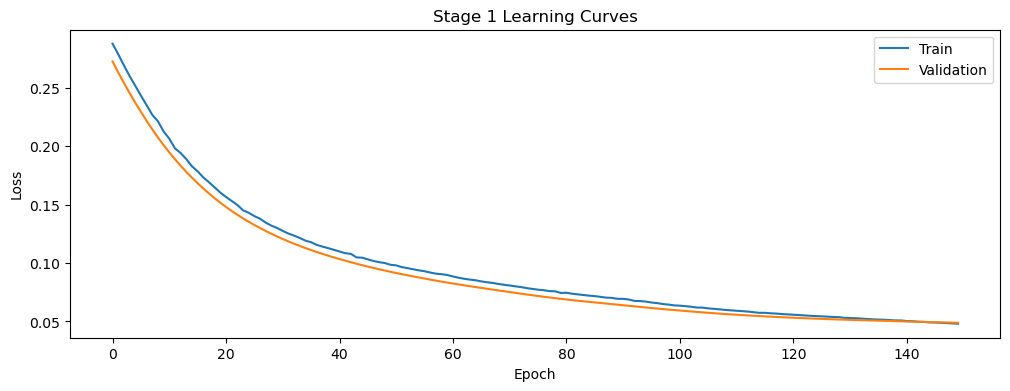

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(history_stage1.history["loss"], label="Train")
ax.plot(history_stage1.history["val_loss"], label="Validation")
ax.set_title("Stage 1 Learning Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()


In [39]:
eval_with_units(
    "Stage 1 Transfer Model - Real Test",
    transfer_model,
    x_real_test_s,
    y_real_test_s,
    scy,
    y_is_scaled=True,
    t_hit_in_seconds=True
)




Stage 1 Transfer Model - Real Test
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm    65.566    84.567         53.410
 y_hit   mm    91.832   117.531         73.352
 z_hit   mm    66.644    83.027         49.518
vx_hit mm/s   176.735   224.873        139.042
vy_hit mm/s   435.987   560.002        351.451
vz_hit mm/s 1,010.657 1,184.880        618.478
 t_hit   ms   152.570   175.986         87.711


In [40]:
def snapshot_model(model):
    with tf.keras.utils.custom_object_scope({'weighted_mse': weighted_mse}):
        m = tf.keras.models.clone_model(model)
    m.set_weights(model.get_weights())
    return m

# --- run this RIGHT AFTER stage 1 training/eval ---
stage1_model = snapshot_model(transfer_model)
print("Saved stage1_model snapshot.")


Saved stage1_model snapshot.


In [41]:
# Stage 2: unfreeze all layers
for layer in transfer_model.layers:
    layer.trainable = True

transfer_model.compile(
    loss=weighted_mse,
    optimizer=Adam(learning_rate=1e-5),
    metrics=["mean_squared_error"]
)

history_stage2 = transfer_model.fit(
    x_real_train_s, y_real_train_s,
    sample_weight=sample_w_real,
    validation_split=0.2,
    epochs=150,
    verbose=1
)


Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 268ms/step - loss: 0.0487 - mean_squared_error: 0.1205 - val_loss: 0.0496 - val_mean_squared_error: 0.1456
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0486 - mean_squared_error: 0.1203 - val_loss: 0.0496 - val_mean_squared_error: 0.1454
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0485 - mean_squared_error: 0.1201 - val_loss: 0.0495 - val_mean_squared_error: 0.1453
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0485 - mean_squared_error: 0.1199 - val_loss: 0.0495 - val_mean_squared_error: 0.1451
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0482 - mean_squared_error: 0.1197 - val_loss: 0.0494 - val_mean_squared_error: 0.1449
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0481 - mean_squared_error: 0.1195 - val_loss: 0.0493 - val_mean_squared_error: 0.1448
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0481 - mean_squared_error: 0.1193 - val_loss: 0.0493 - val_mean

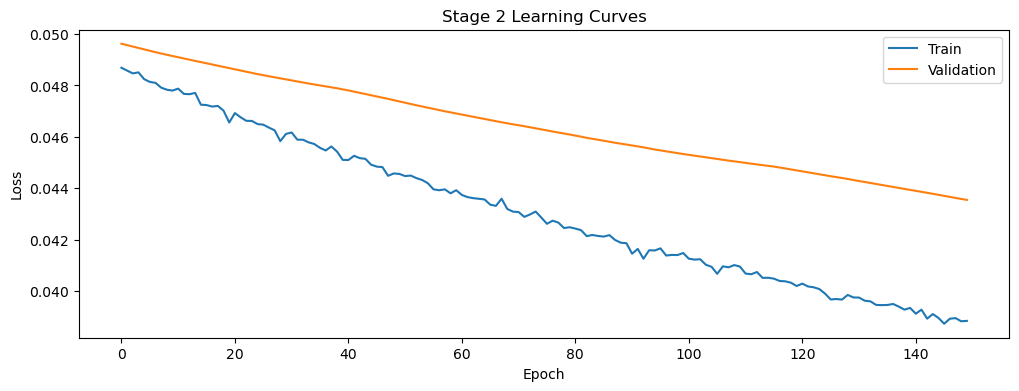

In [42]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(history_stage2.history["loss"], label="Train")
ax.plot(history_stage2.history["val_loss"], label="Validation")
ax.set_title("Stage 2 Learning Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()


In [43]:
eval_with_units(
    "Stage 2 Final Transfer Model - Real Test",
    transfer_model,
    x_real_test_s,
    y_real_test_s,
    scy,
    y_is_scaled=True,
    t_hit_in_seconds=True
)




Stage 2 Final Transfer Model - Real Test
target unit     MAE      RMSE  STD_abs_error
 x_hit   mm  57.135    81.341         57.896
 y_hit   mm  99.944   127.219         78.714
 z_hit   mm  66.819    80.343         44.611
vx_hit mm/s 155.406   203.509        131.396
vy_hit mm/s 412.441   488.557        261.880
vz_hit mm/s 977.191 1,137.547        582.333
 t_hit   ms 146.665   170.300         86.554


In [44]:
stage2_model = snapshot_model(transfer_model)
print("Saved stage2_model snapshot.")

# --- run once (any time after broad + matched are trained) ---
broad_model = snapshot_model(ball_predictor)
matched_model = snapshot_model(transfer_model_matched)
print("Saved broad_model and matched_model snapshots.")




Saved stage2_model snapshot.
Saved broad_model and matched_model snapshots.


In [45]:
# --- final comparison on real test set ---
eval_with_units("Broad model - Real Test",   broad_model,   x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units("Matched model - Real Test", matched_model, x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units("Stage 1 model - Real Test", stage1_model,  x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units("Stage 2 model - Real Test", stage2_model,  x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)




Broad model - Real Test
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm    83.618   105.819         64.851
 y_hit   mm   147.849   188.321        116.643
 z_hit   mm   203.709   267.484        173.350
vx_hit mm/s   281.474   379.368        254.347
vy_hit mm/s 2,123.192 2,173.843        466.529
vz_hit mm/s 1,891.296 2,378.883      1,442.943
 t_hit   ms   309.104   332.917        123.646

Matched model - Real Test
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm    77.800    92.237         49.547
 y_hit   mm    75.965    99.014         63.507
 z_hit   mm   200.881   230.122        112.264
vx_hit mm/s   212.851   290.824        198.174
vy_hit mm/s 1,830.584 1,888.533        464.240
vz_hit mm/s 1,378.269 1,555.922        721.989
 t_hit   ms   233.129   274.475        144.869

Stage 1 model - Real Test
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm    65.566    84.567         53.410
 y_hit   mm    91.832   117.531         73.352
 z_hit   mm    66.644    83.

In [46]:
from pathlib import Path
import joblib

export_dir = Path("../models/ann_stage2_6pt_verified")
export_dir.mkdir(parents=True, exist_ok=True)

deploy_model = stage2_model   # or transfer_model / matched_model / broad_model
deploy_model.save(export_dir / "ball_predictor.keras")
joblib.dump(scx, export_dir / "scx.joblib")
joblib.dump(scy, export_dir / "scy.joblib")

print("Saved model + scalers to:", export_dir.resolve())


Saved model + scalers to: C:\Users\rocky\Personal\UBC\Year 4\IGEN 430\TableTennis_Software_Firmware\transfer_learning\models\ann_stage2_6pt_verified
